#**Analisi e segmentazione della clientela di un'azienda di servizi finanziari**

### **1) Caricamento del dataset**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import os
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
import csv

drive.mount('/content/drive')

file_path = ('/content/drive/MyDrive/credit_card_customers.csv')

df = pd.read_csv(file_path)

print("\nInfo dataset:")
display(df.info())

# Statistiche generali
print("\n Statistiche generali del dataset: \n")
print(df.describe())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   f

None


 Statistiche generali del dataset: 

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.

### **2) Preparazione dei dati per il Clustering**

#### 2.1) Rimozione della Colonna Identificativa (CUST_ID)

In [20]:
df_clustering = df.drop('CUST_ID', axis=1)

print("Colonna 'CUST_ID' rimossa.")
print("Shape del dataset per il clustering:", df_clustering.shape)

Colonna 'CUST_ID' rimossa.
Shape del dataset per il clustering: (8950, 17)


#### 2.2) Gestione dei valori nulli (MINIMUM_PAYMENTS e CREDIT_LIMIT)

In [21]:
# Gestione dei valori nulli nel DataFrame df_clustering

# Evidenziamo i valori null prima della gestione

print("Valori mancanti prima della gestione:")
display(df_clustering.isnull().sum()[df_clustering.isnull().sum() > 0])

# Nel momento in cui minimum_payment > payment allora adegualo a payment
# Anche per gli NA di minimum_payment, sostituiscili con i pagamenti corrispondenti o la mediana se Payments è 0
# Useremo df_clustering['PAYMENTS'] come base per fillna e where
df_clustering['MINIMUM_PAYMENTS'] = df_clustering['MINIMUM_PAYMENTS'].fillna(df_clustering['PAYMENTS'])
df_clustering['MINIMUM_PAYMENTS'] = np.where(
    df_clustering['MINIMUM_PAYMENTS'] > df_clustering['PAYMENTS'],
    df_clustering['PAYMENTS'],
    df_clustering['MINIMUM_PAYMENTS']
)

# Sostituzione degli NA di CREDIT_LIMIT con la mediana della colonna

df_clustering['CREDIT_LIMIT'] = df_clustering['CREDIT_LIMIT'].fillna(df_clustering['CREDIT_LIMIT'].median())

# Evidenziamo i valori null dopo la gestione per verificare la corretta esecuzione

print("\nValori mancanti dopo la gestione:")
display(df_clustering.isnull().sum()[df_clustering.isnull().sum() > 0])
print("Valori nulli gestiti per 'MINIMUM_PAYMENTS' e 'CREDIT_LIMIT'.")

df_clean_non_transformed = df_clustering.copy()

Valori mancanti prima della gestione:


,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313



Valori mancanti dopo la gestione:


,0


Valori nulli gestiti per 'MINIMUM_PAYMENTS' e 'CREDIT_LIMIT'.


#### 2.3) Log-Trasformazione delle Variabili Skewed

In [22]:
# Identificazione delle colonne di importo che possono essere asimmetriche e necessitano della trasformazione logaritmica
amount_cols = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT'
]

# Applicazione della trasformazione logaritmica
for c in amount_cols:
    # Verifica se la colonna esiste e se contiene valori non negativi prima di applicare log1p
    if c in df_clustering.columns and (df_clustering[c] >= 0).all():
        df_clustering[c] = np.log1p(df_clustering[c])
    elif c in df_clustering.columns and not (df_clustering[c] >= 0).all():
        print(f"Attenzione: La colonna '{c}' contiene valori negativi, la trasformazione log1p non verrà applicata.")

print("Variabili di importo potenzialmente skewed log-trasformate.")
display(df_clustering.head())

Variabili di importo potenzialmente skewed log-trasformate.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,6.908755,5.312231,4.945277,0.000000,12
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,4,0,8.853808,8.319725,6.978531,0.222222,12
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,8.922792,6.434654,6.434654,0.000000,12
3,7.419183,0.636364,7.313220,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,1,1,8.922792,0.000000,0.000000,0.000000,12
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,7.090910,6.521114,5.504483,0.000000,12


#### 2.4) Standardizzazione delle Features

In [23]:
# Standardizzazione di tutte le colonne numeriche per prepararle al clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns)

print("Dati standardizzati.")
display(df_scaled.head())

Dati standardizzati.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-1.447163,-0.824484,-0.469740,-0.525551,0.36068
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.926060,1.065033,0.966358,0.234227,0.36068
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,1.010229,-0.119300,0.582214,-0.525551,0.36068
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,1.010229,-4.161996,-3.962617,-0.525551,0.36068
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-1.224909,-0.064979,-0.074771,-0.525551,0.36068


#### 2.5) Riduzione della Dimensionalità con PCA

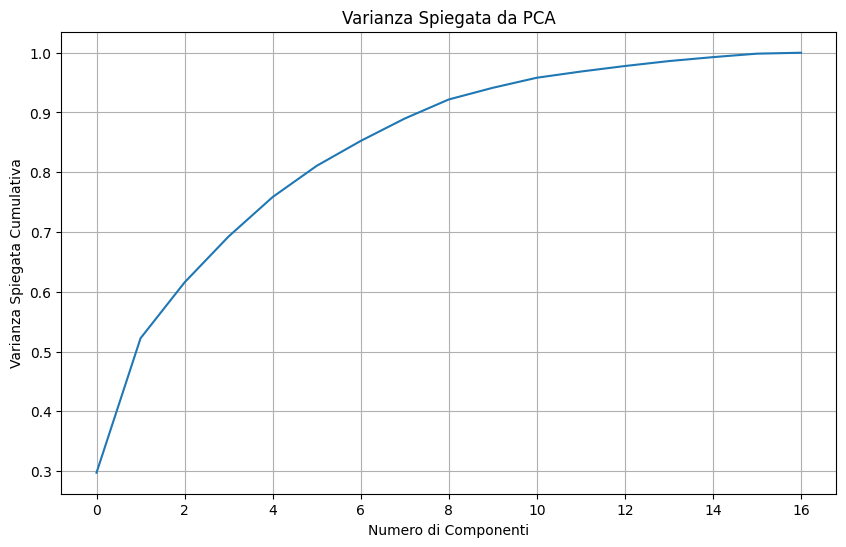

Riduzione della dimensionalità a 8 componenti principali (PCA).
Varianza spiegata dalle componenti selezionate: 0.89


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
0,-0.752307,-2.335511,-0.367515,0.934983,-0.425646,0.242915,-0.648908,-0.576673
1,-2.815330,1.589865,-0.097837,0.951030,1.393099,-0.496435,0.656555,0.471505
2,1.452985,1.116438,2.740530,0.598676,-0.811549,-0.101772,0.043890,0.634964
3,-1.302304,-2.779105,2.522665,-1.681738,-1.608612,2.882608,0.188045,2.412598
4,-1.346107,-0.825585,0.721443,1.661791,-0.759928,-0.551817,-0.656989,-0.165379


In [24]:
# Valutiamo il numero di componenti con una varianza spiegata cumulata
pca = PCA().fit(df_scaled)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.title('Varianza Spiegata da PCA')
plt.grid(True)
plt.show()

# Scegliamo un numero di componenti che spieghi una buona percentuale della varianza

n_components = 8
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i+1}' for i in range(n_components)])

print(f"Riduzione della dimensionalità a {n_components} componenti principali (PCA).")
print(f"Varianza spiegata dalle componenti selezionate: {sum(pca.explained_variance_ratio_):.2f}")
display(df_pca.head())

### **3) Determinazione del numero ottimale di cluster (K-Means)**

#### 3.1) Metodo del Gomito (Elbow Method)

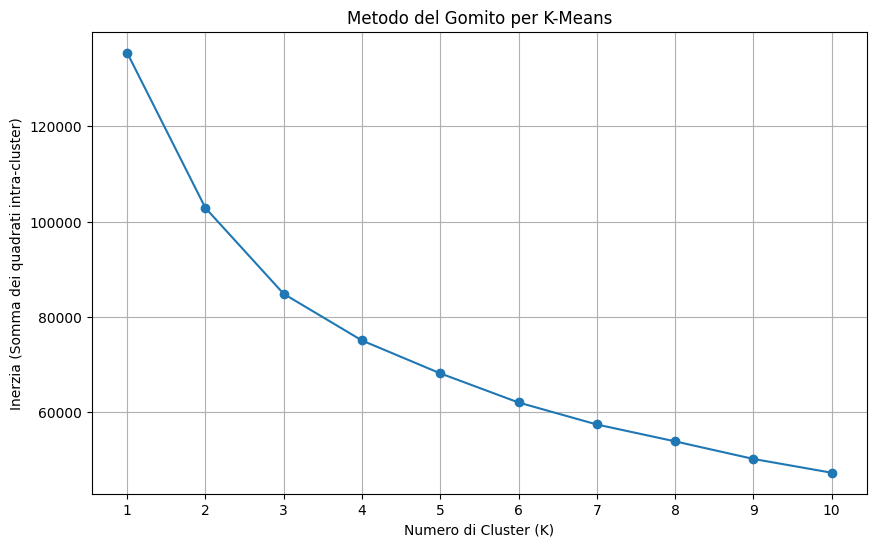

In [25]:
# Elbow Method per trovare il numero ottimale di cluster (K)
inertia = []
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), inertia, marker='o')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Inerzia (Somma dei quadrati intra-cluster)')
plt.title('Metodo del Gomito per K-Means')
plt.grid(True)
plt.xticks(range(1, max_k + 1))
plt.show()



#### 3.2) Analisi del Silhouette Score

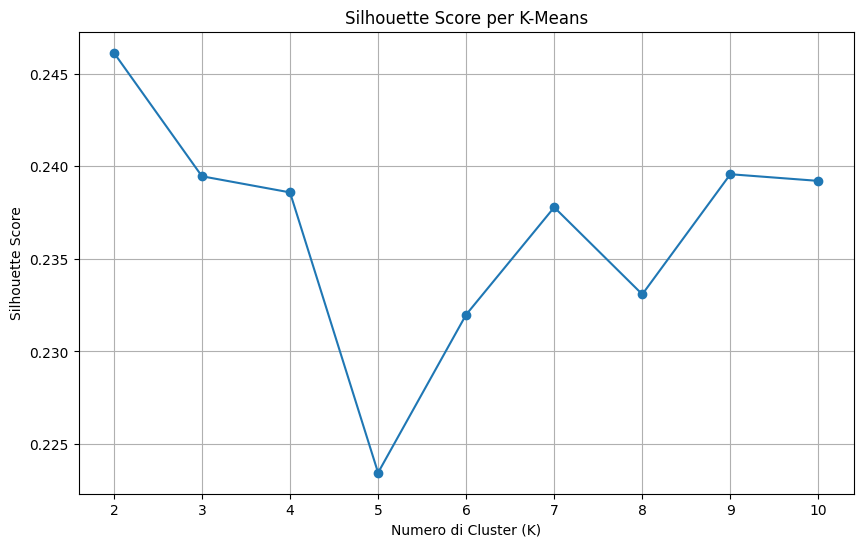

In [26]:
# Calcolo del Silhouette Score per diversi numeri di cluster
silhouette_scores = []

for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    score = silhouette_score(df_pca, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per K-Means')
plt.grid(True)
plt.xticks(range(2, max_k + 1))
plt.show()



### **4) Applicazione del Clustering K-Means e Visualizzazione**

#### 4.1) Applicazione dell'Algoritmo K-Means

In [27]:

k_optimale = 4 # <--- è stato scelto k = 4 in quanto rappresenta un massimo locale per la silhoutte score e allo stesso tempo un buon punti di minimo

kmeans_final = KMeans(n_clusters=k_optimale, random_state=42, n_init=10)
kmeans_final.fit(df_pca)

# Aggiunge le etichette dei cluster al Dataset PCA
df_pca['Cluster'] = kmeans_final.labels_

print(f"Algoritmo K-Means applicato con {k_optimale} cluster.")
print("Distribuzione dei clienti per cluster:")
display(df_pca['Cluster'].value_counts().sort_index())

Algoritmo K-Means applicato con 4 cluster.
Distribuzione dei clienti per cluster:


,count
Cluster,
0,2203
1,2324
2,3065
3,1358


#### 4.3) Visualizzazione dei Cluster (prime 3 Componenti Principali)

In [28]:
import plotly.express as px

# Convertiamo la colonna 'Cluster' in stringa per assicurare una legenda discreta con colori distinti
df_pca['Cluster'] = df_pca['Cluster'].astype(str)

fig = px.scatter_3d(df_pca,
                    x='PC_1',
                    y='PC_2',
                    z='PC_3',
                    color='Cluster', # Ora 'Cluster' è una stringa, quindi sarà trattato come categoria,
                    title=f'Cluster K-Means (K={k_optimale}) visualizzati su PC1, PC2 e PC3 (Interattivo)',
                    height=700)

fig.update_layout(scene=dict(
    xaxis_title='Componente Principale 1',
    yaxis_title='Componente Principale 2',
    zaxis_title='Componente Principale 3'
))

fig.show()

### **5) Definizione dei Cluster**

#### 5.1) Unione delle etichette dei cluster al Dataset Pulito (Non Trasformato)

In [29]:

# Affianchiamo le etichette dei cluster al dataset
df_clean_non_transformed_clustered = df_clean_non_transformed.copy()
df_clean_non_transformed_clustered['Cluster'] = df_pca['Cluster'].astype(int) # Assicurati che il tipo sia consistente

print("Etichette dei cluster unite al DataFrame pulito (senza log-trasformazione/standardizzazione).")
print("Le prime 5 righe del dataset:")
display(df_clean_non_transformed_clustered.head())

Etichette dei cluster unite al DataFrame pulito (senza log-trasformazione/standardizzazione).
Le prime 5 righe del dataset:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,622.066742,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


#### 5.2) Rinomina Colonne del DataFrame

In [30]:
# Definizione di un dizionario per la mappatura dei nomi delle colonne
# Le chiavi sono i nomi attuali, i valori sono i nuovi nomi maggiormente esplicativi
column_rename_map = {
    'BALANCE_FREQUENCY': 'Freq_Aggiornamento_Saldo',
    'ONEOFF_PURCHASES': 'Acquisti_Singoli',
    'INSTALLMENTS_PURCHASES': 'Acquisti_Rateali',
    'CASH_ADVANCE': 'Anticipo_Contanti',
    'PURCHASES_FREQUENCY': 'Freq_Acquisti',
    'ONEOFF_PURCHASES_FREQUENCY': 'Freq_Acquisti_Singoli',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Freq_Acquisti_Rateali',
    'CASH_ADVANCE_FREQUENCY': 'Freq_Anticipo_Contanti',
    'CASH_ADVANCE_TRX': 'Trans_Anticipo_Contanti',
    'PURCHASES_TRX': 'Trans_Acquisti',
    'CREDIT_LIMIT': 'Limite_Credito',
    'PAYMENTS': 'Pagamenti_Totali',
    'MINIMUM_PAYMENTS': 'Pagamenti_Minimi',
    'PRC_FULL_PAYMENT': 'Perc_Pagamento_Completo',
    'TENURE': 'Durata_Servizio_In_Anni'
}

df_renamed = df_clean_non_transformed_clustered.rename(columns=column_rename_map)

print("Nomi delle colonne rinominati:")
display(df_renamed.head())

Nomi delle colonne rinominati (prime 5 righe del DataFrame modificato):


,BALANCE,Freq_Aggiornamento_Saldo,PURCHASES,Acquisti_Singoli,Acquisti_Rateali,Anticipo_Contanti,Freq_Acquisti,Freq_Acquisti_Singoli,Freq_Acquisti_Rateali,Freq_Anticipo_Contanti,Trans_Anticipo_Contanti,Trans_Acquisti,Limite_Credito,Pagamenti_Totali,Pagamenti_Minimi,Perc_Pagamento_Completo,Durata_Servizio_In_Anni,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,622.066742,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


#### 5.3) Valori Medi per Cluster del Dataset Pulito (Non Trasformato)

In [31]:
# Group by Cluster e calcolo dei valori medi per ogni colonna
cluster_profiles_clean_non_transformed = df_renamed.groupby('Cluster').mean()

print("Valori medi delle feature del dataset pulito (non trasformato), divisi per cluster:")
display(cluster_profiles_clean_non_transformed.round(2))

Valori medi delle feature del dataset pulito (non trasformato), divisi per cluster:


,BALANCE,Freq_Aggiornamento_Saldo,PURCHASES,Acquisti_Singoli,Acquisti_Rateali,Anticipo_Contanti,Freq_Acquisti,Freq_Acquisti_Singoli,Freq_Acquisti_Rateali,Freq_Anticipo_Contanti,Trans_Anticipo_Contanti,Trans_Acquisti,Limite_Credito,Pagamenti_Totali,Pagamenti_Minimi,Perc_Pagamento_Completo,Durata_Servizio_In_Anni
Cluster,,,,,,,,,,,,,,,,,
0,639.47,0.94,681.03,74.97,606.89,167.30,0.80,0.05,0.74,0.03,0.56,14.48,3000.79,877.38,365.09,0.27,11.48
1,2143.41,0.98,2813.83,1895.68,918.21,753.89,0.85,0.59,0.56,0.10,2.47,38.20,6587.28,3055.51,792.46,0.20,11.83
2,2421.43,0.95,154.69,127.76,26.98,2087.34,0.10,0.06,0.04,0.29,6.97,1.76,4359.79,1804.91,705.86,0.03,11.43
3,140.17,0.46,342.35,250.38,92.39,178.63,0.27,0.11,0.15,0.03,0.55,4.12,3638.80,696.41,154.15,0.18,11.24


#### 5.4) Visualizzazione dei Valori Medi del Dataset Pulito (Non Trasformato) per Cluster (Heatmap)

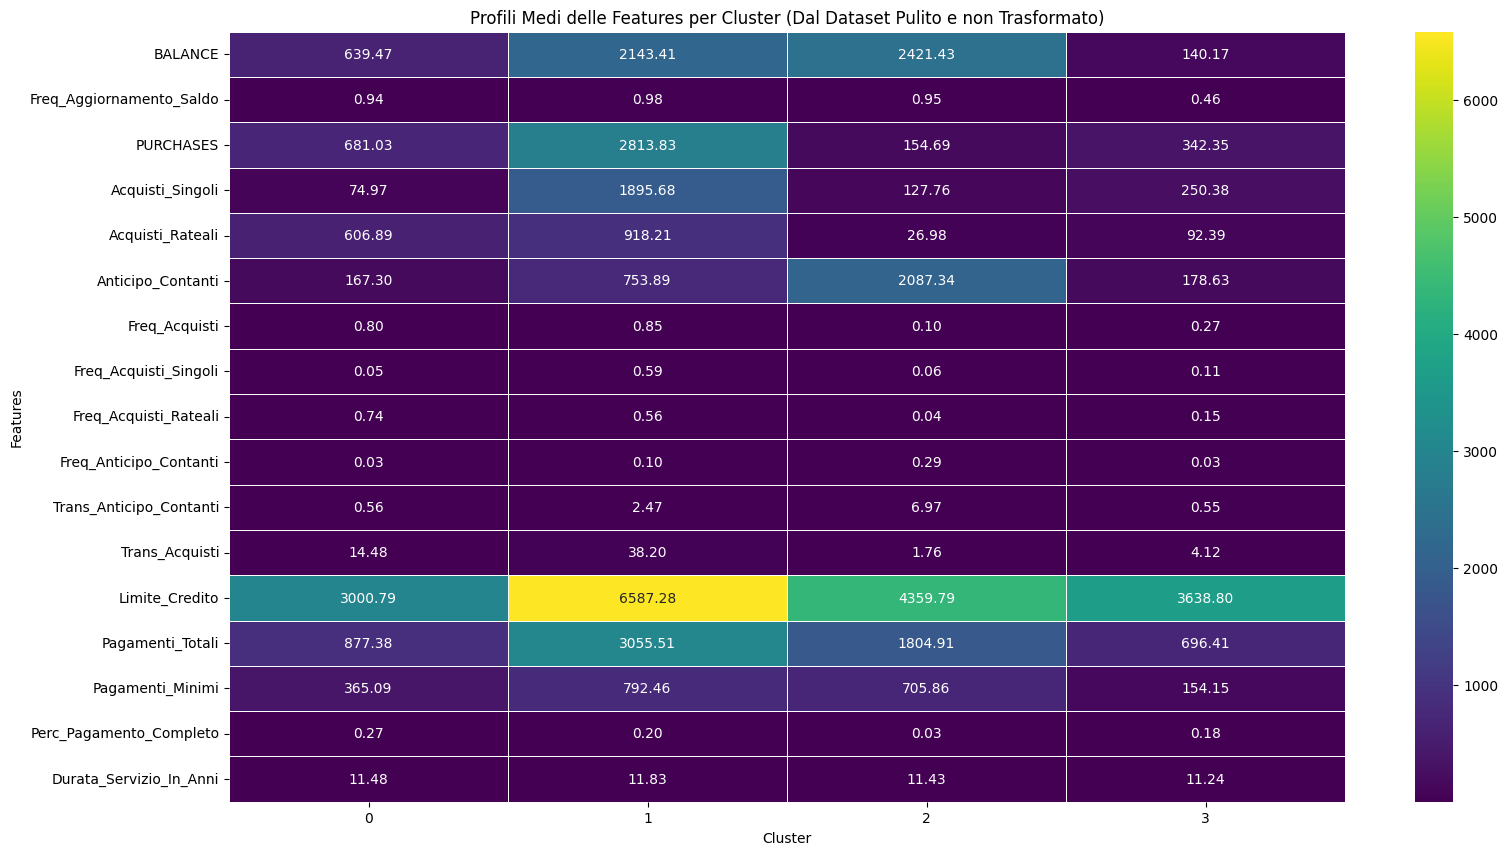

In [32]:
plt.figure(figsize=(18, 10))
sns.heatmap(cluster_profiles_clean_non_transformed.T, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Profili Medi delle Features per Cluster (Dal Dataset Pulito e non Trasformato)')
plt.ylabel('Features')
plt.xlabel('Cluster')
plt.show()



### **6) Interpretazione dei cluster e definizione delle strategie di marketing**

#### Cluster 0: Clienti frequenti e dilazionisti

Questo cluster è caratterizzato da clienti che usano molto la carta per acquisti a rate, con alta frequenza. Pagano regolarmente, coprendo più del minimo, ma tendono a mantenere un saldo. Non usano quasi mai gli anticipi in contanti. L'obiettivo è quello di fidelizzarli, incentivare maggiormente i pagamenti completi e aumentarne l'amount.

Stategia di marketing consigliata:

- Promozioni cashback per aumentare la spesa: se la spesa supera un certo amount al mese è possibile ricevere un cashback.
- Accumulo punti extra o cashback per ogni pagamento a rate che viene completato (per incentivare il completamento dei pagamenti)

#### Cluster 1: Top Clients

Questo è il cluster di clienti di maggior valore. Grandi spenditori, con preferenza per gli acquisti one-off, ma attivi anche nelle rate. Gestiscono in modo esemplare il loro credito, pagando importi elevati e saldando spesso completamente il debito. Uso della carta molto frequente e diversificato, con scarso ricorso agli anticipi. Questa tipologia di clienti è la migliore pertanto bisogna fidelizzarla e massimizzare il loro valore.

Strategia di marketing consigliata:

- aumenti personalizzati del limite di credito
- accesso a prodotti secondari (es. sconti su determinati shop, protezione su acquisti)
- inviti a consulenze personalizzate per far spendere denaro in altre revenues stream.

#### Cluster 2: Clienti forti utilizzatori di anticipi in contante


I clienti appartenenti a questo cluster utilizzano la carta quasi esclusivamente per richiedere anticipi di contante, accumulando così saldi elevati e effettuando pagamenti spesso insufficienti a coprire nemmeno il minimo dovuto. L’utilizzo per acquisti tradizionali è raro o assente. Questo comportamento li rende la tipologia di cliente con il profilo di rischio più elevato, sia in termini di sostenibilità finanziaria sia di probabilità di insolvenza.

Strategia di marketing consigliata:

L’uso intensivo dell’anticipo in contanti evidenzia una scarsa consapevolezza finanziaria, che può essere affrontata con un programma strutturato di comunicazioni educative mirate. Una mail list dedicata può aiutare il cliente a comprendere i costi elevati associati agli anticipi (commissioni, tassi applicati e assenza di periodo di grazia), proponendo al tempo stesso alternative più sostenibili. Parallelamente, è utile introdurre incentivi — come cashback, punti reward o promozioni su categorie di spesa — per incoraggiare un uso più equilibrato e tradizionale della carta di credito. L’obiettivo è favorire un graduale passaggio dall’uso del credito d’emergenza verso modalità di pagamento più sane e meno costose, riducendo così il rischio e aumentando la redditività nel lungo periodo.



#### Cluster 3: Clienti sporadici o inattivi

Clienti inattivi o con un utilizzo molto sporadico della carta. Saldo e acquisti sono minimi, e l'uso degli anticipi in contanti è quasi nullo. I pagamenti sono bassi, ma spesso sufficienti a coprire il poco debito. Rappresentano un segmento con basso engagement e poco valore generato. L'obiettivo è quello di riattivare l’engagement e stimolare l’utilizzo della carta.

Strategia di marketing consigliata:

- Campagne di re-engagement, come bonus di benvenuto al riutilizzo, cashback temporaneo sui primi acquisti o punti reward extra nel primo mese di attività.
- Offerte personalizzate su categorie di interesse rilevate dai dati storici.
- Infine, l’invio di notifiche o promemoria sull'attivazione di servizi aggiuntivi (wallet digitali, pagamenti contactless, app di gestione) può semplificare l’esperienza e consolidare l'abitudine d’uso nel tempo.